In [13]:
import os
import re
import numpy as np
import random
import pandas as pd
from typing import List, Dict, Tuple
import joblib
from pathlib import Path
from sklearn.feature_extraction.text import TfidfVectorizer
import faiss
import json
from sentence_transformers import SentenceTransformer
from IPython.display import display, Markdown
from dataclasses import dataclass
import matplotlib.pyplot as plt


import torch

ARTIFACTS_DIR = Path('artifacts')
ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)
pd.set_option("display.max_colwidth", 140)
pd.set_option("display.width", 180)
pd.set_option("display.precision", 4)

In [14]:
def set_seed(seed: int = 42) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
set_seed(42)
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

In [15]:
with open("knowlege_database.json", 'r', encoding='utf-8') as f:
    data = json.load(f) 

documents = []
for doc_id, doc_content in data.items():
    documents.append({
        "doc_id": doc_content["doc_id"],
        "title": doc_content["title"],
        "text": doc_content["text"]
    })

print(documents)

[{'doc_id': 'doc_01', 'title': 'Грипп: симптомы и течение', 'text': 'Грипп — острое респираторное вирусное заболевание. Основные симптомы: высокая температура (38-40°C), головная боль, ломота в мышцах и суставах, сухой кашель, боль в горле, заложенность носа, слабость. Температура держится 3-5 дней, общая слабость может сохраняться до 2 недель.'}, {'doc_id': 'doc_02', 'title': 'Ангина (острый тонзиллит)', 'text': 'Ангина — воспаление нёбных миндалин, вызванное бактериями или вирусами. Симптомы: сильная боль в горле, усиливающаяся при глотании, температура 38-39°C, увеличение и покраснение миндалин, белый налёт или гнойные пробки, увеличение подчелюстных лимфоузлов, головная боль, слабость.'}, {'doc_id': 'doc_03', 'title': 'Гастрит: воспаление желудка', 'text': 'Гастрит — воспаление слизистой оболочки желудка. Симптомы: боль и тяжесть в верхней части живота после еды, тошнота, отрыжка, изжога, чувство быстрого насыщения, снижение аппетита. При остром гастрите возможна рвота, при хрониче

In [16]:
df = pd.DataFrame(documents)
df

,doc_id,title,text
0,doc_01,Грипп: симптомы и течение,"Грипп — острое респираторное вирусное заболевание. Основные симптомы: высокая температура (38-40°C), головная боль, ломота в мышцах и су..."
1,doc_02,Ангина (острый тонзиллит),"Ангина — воспаление нёбных миндалин, вызванное бактериями или вирусами. Симптомы: сильная боль в горле, усиливающаяся при глотании, темп..."
2,doc_03,Гастрит: воспаление желудка,"Гастрит — воспаление слизистой оболочки желудка. Симптомы: боль и тяжесть в верхней части живота после еды, тошнота, отрыжка, изжога, чу..."
3,doc_04,Мигрень: неврологическое заболевание,"Мигрень — приступообразная головная боль пульсирующего характера. Симптомы: односторонняя боль (редко двусторонняя), длительность 4-72 ч..."
4,doc_05,Аллергический ринит,"Аллергический ринит — воспаление слизистой носа, вызванное аллергенами. Симптомы: чихание, водянистые выделения из носа, заложенность но..."
5,doc_06,Бронхит: воспаление бронхов,"Бронхит — воспаление слизистой оболочки бронхов. Симптомы: кашель (сначала сухой, затем влажный с мокротой), повышение температуры (обыч..."
6,doc_07,Отит: воспаление уха,"Отит — воспаление наружного, среднего или внутреннего уха. Симптомы отита: боль в ухе (стреляющая или ноющая), заложенность уха, снижени..."
7,doc_08,Цистит: воспаление мочевого пузыря,"Цистит — воспаление мочевого пузыря, чаще бактериальной природы. Симптомы: частые позывы к мочеиспусканию (каждые 15-30 минут), боль и ж..."
8,doc_09,Остеохондроз позвоночника,"Остеохондроз — дегенеративное изменение межпозвоночных дисков. Симптомы зависят от отдела: шейный — головные боли, головокружение, боль ..."
9,doc_10,Анемия (малокровие),"Анемия — снижение уровня гемоглобина и/или эритроцитов в крови. Симптомы: бледность кожи и слизистых, общая слабость, повышенная утомляе..."


In [17]:
print('Примеры пары документов')
print(df[:3])

Примеры пары документов
   doc_id                        title  \
0  doc_01    Грипп: симптомы и течение   
1  doc_02    Ангина (острый тонзиллит)   
2  doc_03  Гастрит: воспаление желудка   

                                                                                                                                          text  
0  Грипп — острое респираторное вирусное заболевание. Основные симптомы: высокая температура (38-40°C), головная боль, ломота в мышцах и су...  
1  Ангина — воспаление нёбных миндалин, вызванное бактериями или вирусами. Симптомы: сильная боль в горле, усиливающаяся при глотании, темп...  
2  Гастрит — воспаление слизистой оболочки желудка. Симптомы: боль и тяжесть в верхней части живота после еды, тошнота, отрыжка, изжога, чу...  


In [18]:
def chunk_text(text: str, chunk_size:  24, overlap: 6) -> List[str]:
    words = text.split()
    if chunk_size <= 0:
        raise ValueError("chunk_size должен быть положительным.")
    if overlap >= chunk_size:
        raise ValueError("overlap должен быть меньше chunk_size.")
    
    step = chunk_size - overlap
    chunks = []

    for start in range(0, len(words), step):
        end = start + step
        chunck_words = words[start:end]

        if not chunck_words:
            continue
        chunks.append(" ".join(chunck_words))
        if end >= len(words):
            break
    return chunks



In [19]:
rows = []
for doc in documents:
    chunks = chunk_text(doc["text"], chunk_size=24, overlap=6)
    for chunk_id, chunk_text_value in enumerate(chunks, start=1):
            rows.append(
                {
                    "doc_id": doc["doc_id"],
                    "title": doc["title"],
                    "chunk_id": f'{doc["doc_id"]}_chunk_{chunk_id:02d}',
                    "chunk_text": chunk_text_value,
                }
            )
chunks_df = pd.DataFrame(rows)
chunks_df

,doc_id,title,chunk_id,chunk_text
0,doc_01,Грипп: симптомы и течение,doc_01_chunk_01,"Грипп — острое респираторное вирусное заболевание. Основные симптомы: высокая температура (38-40°C), головная боль, ломота в мышцах и су..."
1,doc_01,Грипп: симптомы и течение,doc_01_chunk_02,"сухой кашель, боль в горле, заложенность носа, слабость. Температура держится 3-5 дней, общая слабость может сохраняться до 2"
2,doc_01,Грипп: симптомы и течение,doc_01_chunk_03,недель.
3,doc_02,Ангина (острый тонзиллит),doc_02_chunk_01,"Ангина — воспаление нёбных миндалин, вызванное бактериями или вирусами. Симптомы: сильная боль в горле, усиливающаяся при глотании, темп..."
4,doc_02,Ангина (острый тонзиллит),doc_02_chunk_02,"38-39°C, увеличение и покраснение миндалин, белый налёт или гнойные пробки, увеличение подчелюстных лимфоузлов, головная боль, слабость."
5,doc_03,Гастрит: воспаление желудка,doc_03_chunk_01,"Гастрит — воспаление слизистой оболочки желудка. Симптомы: боль и тяжесть в верхней части живота после еды, тошнота, отрыжка,"
6,doc_03,Гастрит: воспаление желудка,doc_03_chunk_02,"изжога, чувство быстрого насыщения, снижение аппетита. При остром гастрите возможна рвота, при хроническом — чередование обострений и ре..."
7,doc_04,Мигрень: неврологическое заболевание,doc_04_chunk_01,"Мигрень — приступообразная головная боль пульсирующего характера. Симптомы: односторонняя боль (редко двусторонняя), длительность 4-72 ч..."
8,doc_04,Мигрень: неврологическое заболевание,doc_04_chunk_02,"и звукам, тошнота, рвота. У некоторых пациентов возникает аура — зрительные или сенсорные нарушения перед приступом."
9,doc_05,Аллергический ринит,doc_05_chunk_01,"Аллергический ринит — воспаление слизистой носа, вызванное аллергенами. Симптомы: чихание, водянистые выделения из носа, заложенность но..."


В данном ноутбуке выбрана медицинская область. Я считаю, что по ней разумно строить mini-rag систему, поскольку медицина яляется специалезированной областью, в которой легко выделить подобласти, в которых искать ответ на вопрос. Также в этой области много специализированных статей с четкими формулировками симптомов заюолеваний, способов лечения и врачебных рекомендаций.

In [20]:
class SentenceTransformersBackend():
    def __init__(self, model_name: str, device: str = "cpu") -> None: 
        self.model_name = model_name
        self.model = SentenceTransformer(model_name, device=device)
        self.backend_name = f"SentenceTransformer: {model_name}"

    def fit_documents(self, texts: List[str]) -> np.ndarray:
        vectors = self.model.encode(
            texts,
            batch_size=16,
            show_progress_bar=False,
            convert_to_numpy=True,
            normalize_embeddings=True,
        )
        return vectors.astype("float32")

    def encode_queries(self, texts: List[str]) -> np.ndarray:
        vectors = self.model.encode(
            texts,
            batch_size=16,
            show_progress_bar=False,
            convert_to_numpy=True,
            normalize_embeddings=True,
        )
        return vectors.astype("float32")


def build_chunks(
    docs: List[Dict[str, str]],
    chunk_size: int,
    overlap: int,
) -> List[Dict[str, object]]:
    rows: List[Dict[str, object]] = []
    for doc in docs:
        parts = chunk_text(doc["text"], chunk_size=chunk_size, overlap=overlap)
        for chunk_idx, chunk_text_value in enumerate(parts):
            rows.append(
                {
                    "doc_id": doc["doc_id"],
                    "title": doc["title"],
                    "chunk_id": f"{doc['doc_id']}_chunk_{chunk_idx}",
                    "chunk_idx": chunk_idx,
                    "chunk_text": chunk_text_value,
                }
            )
    return rows


@dataclass
class RetrievalArtifacts:
    backend_name: str
    backend: SentenceTransformersBackend
    chunks_df: pd.DataFrame
    chunk_vectors: np.ndarray
    index: object


def build_retriever(
    docs: List[Dict[str, str]],
    chunk_size: int = 24,
    overlap: int = 6,
    device: str = "cpu",
    model_name: str = "sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2",
) -> RetrievalArtifacts:
    chunks = build_chunks(docs, chunk_size=chunk_size, overlap=overlap)
    chunks_df = pd.DataFrame(chunks)

    backend = SentenceTransformersBackend(model_name=model_name,device=device)
    chunk_vectors = backend.fit_documents(chunks_df["chunk_text"].tolist())


    index = faiss.IndexFlatIP(chunk_vectors.shape[1])
    index.add(chunk_vectors)

    return RetrievalArtifacts(
        backend_name=backend.backend_name,
        backend=backend,
        chunks_df=chunks_df,
        chunk_vectors=chunk_vectors,
        index=index,
    )


def search_chunks(
    query: str,
    artifacts: RetrievalArtifacts,
    top_k: int = 3,
) -> pd.DataFrame:
    query_vector = artifacts.backend.encode_queries([query]).astype("float32")
    scores, indices = artifacts.index.search(query_vector, top_k)

    rows = []
    for rank, (score, idx) in enumerate(zip(scores[0], indices[0]), start=1):
        chunk_row = artifacts.chunks_df.iloc[int(idx)]
        rows.append(
            {
                "rank": rank,
                "score": float(score),
                "doc_id": chunk_row["doc_id"],
                "title": chunk_row["title"],
                "chunk_id": chunk_row["chunk_id"],
                "chunk_text": chunk_row["chunk_text"],
            }
        )
    return pd.DataFrame(rows)

def unique_doc_order(result_df: pd.DataFrame) -> List[str]:
    seen = set()
    ordered = []
    for doc_id in result_df["doc_id"].tolist():
        if doc_id not in seen:
            seen.add(doc_id)
            ordered.append(doc_id)
    return ordered


def evaluate_query(
    query: str,
    relevant_doc_ids: List[str],
    artifacts: RetrievalArtifacts,
    top_k: int = 3,
) -> Dict[str, object]:
    result_df = search_chunks(query, artifacts=artifacts, top_k=top_k)
    predicted_doc_ids = unique_doc_order(result_df)

    hit = int(any(doc_id in predicted_doc_ids for doc_id in relevant_doc_ids))
    recall = sum(doc_id in predicted_doc_ids for doc_id in relevant_doc_ids) / len(relevant_doc_ids)

    first_relevant_rank = None
    for idx, doc_id in enumerate(predicted_doc_ids, start=1):
        if doc_id in relevant_doc_ids:
            first_relevant_rank = idx
            break

    mrr = 0.0 if first_relevant_rank is None else 1.0 / first_relevant_rank

    return {
        "predicted_doc_ids": predicted_doc_ids,
        "hit": hit,
        "recall": recall,
        "first_relevant_rank": first_relevant_rank,
        "mrr": mrr,
        "result_df": result_df,
    }


def evaluate_benchmark(
    benchmark_rows: List[Dict[str, object]],
    artifacts: RetrievalArtifacts,
    top_k: int = 3,
) -> pd.DataFrame:
    rows = []
    for row in benchmark_rows:
        metrics = evaluate_query(
            query=row["query"],
            relevant_doc_ids=row["relevant_doc_ids"],
            artifacts=artifacts,
            top_k=top_k,
        )
        rows.append(
            {
                "query_id": row["query_id"],
                "query": row["query"],
                "relevant_doc_ids": ", ".join(row["relevant_doc_ids"]),
                "predicted_doc_ids": ", ".join(metrics["predicted_doc_ids"]),
                f"hit@{top_k}": metrics["hit"],
                f"recall@{top_k}": metrics["recall"],
                f"MRR@{top_k}": metrics["mrr"],
                "first_relevant_rank": metrics["first_relevant_rank"],
            }
        )
    return pd.DataFrame(rows)

In [21]:
MODEL_NAME = "sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2"
dense_embedings = SentenceTransformersBackend(model_name= MODEL_NAME,device=DEVICE)
print("Используем dense-модель эмбеддингов.")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Используем dense-модель эмбеддингов.


In [22]:
baseline_chunk_size = 24
baseline_overlap = 6

artifacts = build_retriever(
    documents,
    chunk_size=baseline_chunk_size,
    overlap=baseline_overlap,
    device=DEVICE,
)

print("Количество чанков:", len(artifacts.chunks_df))
display(artifacts.chunks_df.head())
sample_queries = [
    "Какие симптомы у гриппа?",
    "Что такое анемия?",
    "Какие симптомы у отита?",
]

for query in sample_queries:
    display(Markdown(f"### Запрос: {query}"))
    display(search_chunks(query, artifacts=artifacts, top_k=3)[["rank", "score", "doc_id", "title", "chunk_text"]])

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Количество чанков: 52


,doc_id,title,chunk_id,chunk_idx,chunk_text
0,doc_01,Грипп: симптомы и течение,doc_01_chunk_0,0,"Грипп — острое респираторное вирусное заболевание. Основные симптомы: высокая температура (38-40°C), головная боль, ломота в мышцах и су..."
1,doc_01,Грипп: симптомы и течение,doc_01_chunk_1,1,"сухой кашель, боль в горле, заложенность носа, слабость. Температура держится 3-5 дней, общая слабость может сохраняться до 2"
2,doc_01,Грипп: симптомы и течение,doc_01_chunk_2,2,недель.
3,doc_02,Ангина (острый тонзиллит),doc_02_chunk_0,0,"Ангина — воспаление нёбных миндалин, вызванное бактериями или вирусами. Симптомы: сильная боль в горле, усиливающаяся при глотании, темп..."
4,doc_02,Ангина (острый тонзиллит),doc_02_chunk_1,1,"38-39°C, увеличение и покраснение миндалин, белый налёт или гнойные пробки, увеличение подчелюстных лимфоузлов, головная боль, слабость."


### Запрос: Какие симптомы у гриппа?

,rank,score,doc_id,title,chunk_text
0,1,0.6555,doc_01,Грипп: симптомы и течение,"Грипп — острое респираторное вирусное заболевание. Основные симптомы: высокая температура (38-40°C), головная боль, ломота в мышцах и су..."
1,2,0.6057,doc_11,Пневмония: воспаление лёгких,"Пневмония — инфекционное воспаление лёгочной ткани. Симптомы: высокая температура до 39-40°C, озноб, кашель с гнойной мокротой, одышка в"
2,3,0.6024,doc_19,Сахарный диабет 2 типа,"инфекции, онемение и покалывание в стопах."


### Запрос: Что такое анемия?

,rank,score,doc_id,title,chunk_text
0,1,0.8407,doc_10,Анемия (малокровие),"Анемия — снижение уровня гемоглобина и/или эритроцитов в крови. Симптомы: бледность кожи и слизистых, общая слабость, повышенная утомляе..."
1,2,0.4811,doc_16,Геморрой: варикозное расширение вен прямой кишки,"ануса, зуд и жжение в заднем проходе, ощущение инородного тела, выпадение геморроидальных узлов при натуживании, отёк и покраснение"
2,3,0.4592,doc_16,Геморрой: варикозное расширение вен прямой кишки,"Геморрой — расширение геморроидальных вен прямой кишки. Симптомы: кровотечение алой кровью при дефекации, боль и дискомфорт в области"


### Запрос: Какие симптомы у отита?

,rank,score,doc_id,title,chunk_text
0,1,0.7270,doc_03,Гастрит: воспаление желудка,"изжога, чувство быстрого насыщения, снижение аппетита. При остром гастрите возможна рвота, при хроническом — чередование обострений и ре..."
1,2,0.7015,doc_02,Ангина (острый тонзиллит),"38-39°C, увеличение и покраснение миндалин, белый налёт или гнойные пробки, увеличение подчелюстных лимфоузлов, головная боль, слабость."
2,3,0.6849,doc_13,Панкреатит: воспаление поджелудочной железы,"(не приносящая облегчения), вздутие живота, диарея, повышение температуры, учащённое сердцебиение. Боль усиливается после еды и алкоголя."


In [23]:
benchmark_queries: List[Dict[str, object]] = [
    {
        "query_id": "q01",
        "query": "Что такое острый тонзилит?",
        "relevant_doc_ids": ["doc_02"],
    },
    {
        "query_id": "q02",
        "query": "Какие сиптомы у гастрита?",
        "relevant_doc_ids": ["doc_03"],
    },
    {
        "query_id": "q03",
        "query": "Что такое аура при мигрени?",
        "relevant_doc_ids": ["doc_04"],
    },
    {
        "query_id": "q04",
        "query": "Какие симптомы у цистита?",
        "relevant_doc_ids": ["doc_08"],
    },
    {
        "query_id": "q05",
        "query": "Сниженный гемоглобин - это симптом какого заболевания?",
        "relevant_doc_ids": ["doc_10"],
    },
    {
        "query_id": "q06",
        "query": "Что такое расширение вен на ногах?",
        "relevant_doc_ids": ["doc_14"],
    },

    {
        "query_id": "q07",
        "query": "Какие сиптомы у депрессии?",
        "relevant_doc_ids": ["doc_15"],
    },
    {
        "query_id": "q08",
        "query": "Что такое псориаз?",
        "relevant_doc_ids": ["doc_18"],
    },
]


In [24]:
baseline_eval_k3 = evaluate_benchmark(benchmark_queries, artifacts=artifacts, top_k=3)
display(baseline_eval_k3)

summary_k3 = pd.DataFrame(
    {
        "metric": ["mean_hit@3", "mean_recall@3", "mean_MRR@3"],
        "value": [
            baseline_eval_k3["hit@3"].mean(),
            baseline_eval_k3["recall@3"].mean(),
            baseline_eval_k3["MRR@3"].mean(),
        ],
    }
)
display(summary_k3)

,query_id,query,relevant_doc_ids,predicted_doc_ids,hit@3,recall@3,MRR@3,first_relevant_rank
0,q01,Что такое острый тонзилит?,doc_02,"doc_16, doc_12, doc_10",0,0.0,0.0,NaN
1,q02,Какие сиптомы у гастрита?,doc_03,"doc_16, doc_11, doc_14",0,0.0,0.0,NaN
2,q03,Что такое аура при мигрени?,doc_04,"doc_16, doc_02, doc_14",0,0.0,0.0,NaN
3,q04,Какие симптомы у цистита?,doc_08,"doc_02, doc_16, doc_17",0,0.0,0.0,NaN
4,q05,Сниженный гемоглобин - это симптом какого заболевания?,doc_10,"doc_10, doc_16, doc_01",1,1.0,1.0,1.0
5,q06,Что такое расширение вен на ногах?,doc_14,"doc_14, doc_09, doc_16",1,1.0,1.0,1.0
6,q07,Какие сиптомы у депрессии?,doc_15,"doc_15, doc_17",1,1.0,1.0,1.0
7,q08,Что такое псориаз?,doc_18,"doc_04, doc_15, doc_09",0,0.0,0.0,NaN


,metric,value
0,mean_hit@3,0.375
1,mean_recall@3,0.375
2,mean_MRR@3,0.375


,top_k,mean_hit,mean_recall,mean_MRR
0,1,0.375,0.375,0.375
1,2,0.375,0.375,0.375
2,3,0.375,0.375,0.375
3,4,0.375,0.375,0.375
4,5,0.375,0.375,0.375


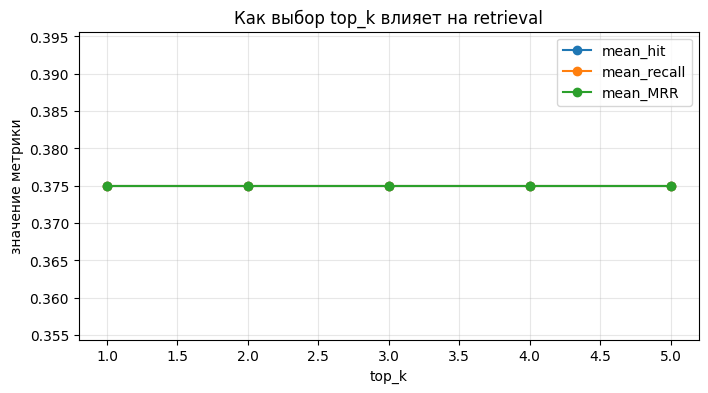

In [25]:
topk_rows = []

for top_k in [1, 2, 3, 4, 5]:
    eval_df = evaluate_benchmark(benchmark_queries, artifacts=artifacts, top_k=top_k)
    topk_rows.append(
        {
            "top_k": top_k,
            "mean_hit": eval_df[f"hit@{top_k}"].mean(),
            "mean_recall": eval_df[f"recall@{top_k}"].mean(),
            "mean_MRR": eval_df[f"MRR@{top_k}"].mean(),
        }
    )

topk_df = pd.DataFrame(topk_rows)
display(topk_df)

plt.figure(figsize=(8, 4))
plt.plot(topk_df["top_k"], topk_df["mean_hit"], marker="o", label="mean_hit")
plt.plot(topk_df["top_k"], topk_df["mean_recall"], marker="o", label="mean_recall")
plt.plot(topk_df["top_k"], topk_df["mean_MRR"], marker="o", label="mean_MRR")
plt.xlabel("top_k")
plt.ylabel("значение метрики")
plt.title("Как выбор top_k влияет на retrieval")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

Из графика видно, что наилучшие метрики у top_k=5. Ранее рассматривался top_k=3. Проведем эксперимент со значением равным пяти и сравним с предыдущим.

In [26]:
baseline_eval_k5 = evaluate_benchmark(benchmark_queries, artifacts=artifacts, top_k=5)
display(baseline_eval_k5)

summary_k5 = pd.DataFrame(
    {
        "metric": ["mean_hit@5", "mean_recall@5", "mean_MRR@5"],
        "value": [
            baseline_eval_k5["hit@5"].mean(),
            baseline_eval_k5["recall@5"].mean(),
            baseline_eval_k5["MRR@5"].mean(),
        ],
    }
)
display(summary_k5)

,query_id,query,relevant_doc_ids,predicted_doc_ids,hit@5,recall@5,MRR@5,first_relevant_rank
0,q01,Что такое острый тонзилит?,doc_02,"doc_16, doc_12, doc_10, doc_14",0,0.0,0.0,NaN
1,q02,Какие сиптомы у гастрита?,doc_03,"doc_16, doc_11, doc_14, doc_10, doc_20",0,0.0,0.0,NaN
2,q03,Что такое аура при мигрени?,doc_04,"doc_16, doc_02, doc_14, doc_05, doc_12",0,0.0,0.0,NaN
3,q04,Какие симптомы у цистита?,doc_08,"doc_02, doc_16, doc_17, doc_03, doc_12",0,0.0,0.0,NaN
4,q05,Сниженный гемоглобин - это симптом какого заболевания?,doc_10,"doc_10, doc_16, doc_01",1,1.0,1.0,1.0
5,q06,Что такое расширение вен на ногах?,doc_14,"doc_14, doc_09, doc_16, doc_10",1,1.0,1.0,1.0
6,q07,Какие сиптомы у депрессии?,doc_15,"doc_15, doc_17, doc_11, doc_13",1,1.0,1.0,1.0
7,q08,Что такое псориаз?,doc_18,"doc_04, doc_15, doc_09, doc_17",0,0.0,0.0,NaN


,metric,value
0,mean_hit@5,0.375
1,mean_recall@5,0.375
2,mean_MRR@5,0.375


За счет увеличения числа возможных наиболее релевантных документов метрики выросли, но только потому, что из большего количества вероятность найти тоже выше, не все из них будут  релевантны для запроса.

Обновление базы знаний  

In [27]:
new_documents: List[Dict[str, str]] = [
    {
        "doc_id": "doc_21",
        "title": "Корь: симптомы и осложнения",
        "text": "Корь — острое вирусное заболевание с воздушно-капельным механизмом передачи. Инкубационный период длится 9-11 дней. Основные симптомы: высокая температура до 39-40°C, сухой кашель, насморк, конъюнктивит (покраснение глаз и светобоязнь), пятна Бельского-Филатова-Коплика на слизистой щёк (мелкие беловатые пятнышки). На 4-5 день болезни появляется сыпь: сначала на лице и за ушами, затем распространяется на туловище и конечности. Сыпь представляет собой яркие красные пятна, склонные к слиянию. Осложнения кори: пневмония, отит, ларингит со стенозом гортани (ложный круп), энцефалит. Наиболее опасна корь для детей до 5 лет и взрослых. Специфического лечения нет, только симптоматическое. Профилактика — вакцинация КПК (корь, паротит, краснуха).",
    },
    {
        "doc_id": "doc_22",
        "title": "Ветряная оспа (ветрянка): течение и лечение",
        "text": "Ветряная оспа — высококонтагиозное вирусное заболевание, вызываемое вирусом варицелла-зостер. Передаётся воздушно-капельным путём. Инкубационный период составляет 10-21 день. Симптомы: повышение температуры (обычно до 38-38.5°C), слабость, головная боль. Характерный признак — сыпь, которая появляется волнообразно каждые 2-3 дня. Элементы сыпи проходят стадии: пятно → папула (узелок) → везикула (пузырёк с прозрачным содержимым) → корочка. Сыпь сопровождается сильным зудом. Одновременно на теле могут присутствовать элементы разных стадий. Заразным больной становится за 1-2 дня до появления сыпи и до 5 дней после последних высыпаний. Лечение: постельный режим при температуре, обработка элементов сыпи зелёнкой или лосьонами с каламином, антигистаминные препараты для уменьшения зуда. Осложнения: вторичная бактериальная инфекция (нагноение везикул), ветряночный энцефалит, пневмония. У взрослых болезнь протекает тяжелее, чем у детей. После перенесённого заболевания формируется пожизненный иммунитет, но вирус сохраняется в нервных ганглиях и может реактивироваться в виде опоясывающего лишая (herpes zoster).",
    },
]

updated_documents = documents + new_documents

display(pd.DataFrame(new_documents)[["doc_id", "title"]])

new_queries = [
    "Как лечить корь?",
    "Почему взрослые сложнее переносят ветрянку?",
]

display(Markdown("### Как baseline-база отвечает на новые запросы"))
for query in new_queries:
    display(Markdown(f"**Запрос:** {query}"))
    display(search_chunks(query, artifacts=artifacts, top_k=3)[["rank", "score", "doc_id", "title", "chunk_text"]])

,doc_id,title
0,doc_21,Корь: симптомы и осложнения
1,doc_22,Ветряная оспа (ветрянка): течение и лечение


### Как baseline-база отвечает на новые запросы

**Запрос:** Как лечить корь?

,rank,score,doc_id,title,chunk_text
0,1,0.4615,doc_10,Анемия (малокровие),мясу).
1,2,0.4005,doc_16,Геморрой: варикозное расширение вен прямой кишки,вокруг ануса.
2,3,0.3980,doc_19,Сахарный диабет 2 типа,"инфекции, онемение и покалывание в стопах."


**Запрос:** Почему взрослые сложнее переносят ветрянку?

,rank,score,doc_id,title,chunk_text
0,1,0.4530,doc_17,Синдром раздражённого кишечника (СРК),на фоне стресса.
1,2,0.4138,doc_11,Пневмония: воспаление лёгких,"покое, боль в грудной клетке при дыхании, учащённое дыхание, сильная слабость, потливость по ночам. У пожилых людей симптомы"
2,3,0.4099,doc_20,Гипертония: повышенное артериальное давление,"в ушах, мелькание ""мушек"" перед глазами, одышка при нагрузке, покраснение лица, часто гипертония долгое время протекает бессимптомно и"


In [28]:
updated_artifacts = build_retriever(
    updated_documents,
    chunk_size=baseline_chunk_size,
    overlap=baseline_overlap,
    device=DEVICE,
)

extended_benchmark_queries = benchmark_queries + [
    {
        "query_id": "q09",
        "query": "Как лечить корь?",
        "relevant_doc_ids": ["doc_21"],
    },
    {
        "query_id": "q10",
        "query": "Почему взрослые сложнее переносят ветрянку?",
        "relevant_doc_ids": ["doc_22"],
    },
]

before_update_eval = evaluate_benchmark(extended_benchmark_queries, artifacts=artifacts, top_k=3)
after_update_eval = evaluate_benchmark(extended_benchmark_queries, artifacts=updated_artifacts, top_k=3)

comparison_df = before_update_eval.merge(
    after_update_eval,
    on=["query_id", "query", "relevant_doc_ids"],
    suffixes=("_before", "_after"),
)

display(comparison_df)

summary_comparison_df = pd.DataFrame(
    {
        "metric": ["mean_hit@3", "mean_recall@3", "mean_MRR@3"],
        "before_update": [
            before_update_eval["hit@3"].mean(),
            before_update_eval["recall@3"].mean(),
            before_update_eval["MRR@3"].mean(),
        ],
        "after_update": [
            after_update_eval["hit@3"].mean(),
            after_update_eval["recall@3"].mean(),
            after_update_eval["MRR@3"].mean(),
        ],
    }
)
summary_comparison_df["delta"] = summary_comparison_df["after_update"] - summary_comparison_df["before_update"]
display(summary_comparison_df)

display(Markdown("### Как updated-база отвечает на новые запросы"))
for query in new_queries:
    display(Markdown(f"**Запрос:** {query}"))
    display(search_chunks(query, artifacts=updated_artifacts, top_k=3)[["rank", "score", "doc_id", "title", "chunk_text"]])

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


,query_id,query,relevant_doc_ids,predicted_doc_ids_before,hit@3_before,recall@3_before,MRR@3_before,first_relevant_rank_before,predicted_doc_ids_after,hit@3_after,recall@3_after,MRR@3_after,first_relevant_rank_after
0,q01,Что такое острый тонзилит?,doc_02,"doc_16, doc_12, doc_10",0,0.0,0.0,NaN,"doc_16, doc_22, doc_12",0,0.0,0.0,NaN
1,q02,Какие сиптомы у гастрита?,doc_03,"doc_16, doc_11, doc_14",0,0.0,0.0,NaN,"doc_16, doc_11, doc_14",0,0.0,0.0,NaN
2,q03,Что такое аура при мигрени?,doc_04,"doc_16, doc_02, doc_14",0,0.0,0.0,NaN,"doc_16, doc_02, doc_14",0,0.0,0.0,NaN
3,q04,Какие симптомы у цистита?,doc_08,"doc_02, doc_16, doc_17",0,0.0,0.0,NaN,"doc_02, doc_16, doc_17",0,0.0,0.0,NaN
4,q05,Сниженный гемоглобин - это симптом какого заболевания?,doc_10,"doc_10, doc_16, doc_01",1,1.0,1.0,1.0,"doc_10, doc_16, doc_01",1,1.0,1.0,1.0
5,q06,Что такое расширение вен на ногах?,doc_14,"doc_14, doc_09, doc_16",1,1.0,1.0,1.0,"doc_14, doc_09, doc_16",1,1.0,1.0,1.0
6,q07,Какие сиптомы у депрессии?,doc_15,"doc_15, doc_17",1,1.0,1.0,1.0,"doc_15, doc_17",1,1.0,1.0,1.0
7,q08,Что такое псориаз?,doc_18,"doc_04, doc_15, doc_09",0,0.0,0.0,NaN,"doc_04, doc_15, doc_09",0,0.0,0.0,NaN
8,q09,Как лечить корь?,doc_21,"doc_10, doc_16, doc_19",0,0.0,0.0,NaN,"doc_21, doc_10, doc_16",1,1.0,1.0,1.0
9,q10,Почему взрослые сложнее переносят ветрянку?,doc_22,"doc_17, doc_11, doc_20",0,0.0,0.0,NaN,"doc_17, doc_11, doc_20",0,0.0,0.0,NaN


,metric,before_update,after_update,delta
0,mean_hit@3,0.3,0.4,0.1
1,mean_recall@3,0.3,0.4,0.1
2,mean_MRR@3,0.3,0.4,0.1


### Как updated-база отвечает на новые запросы

**Запрос:** Как лечить корь?

,rank,score,doc_id,title,chunk_text
0,1,0.4812,doc_21,Корь: симптомы и осложнения,"— вакцинация КПК (корь, паротит, краснуха)."
1,2,0.4615,doc_10,Анемия (малокровие),мясу).
2,3,0.4005,doc_16,Геморрой: варикозное расширение вен прямой кишки,вокруг ануса.


**Запрос:** Почему взрослые сложнее переносят ветрянку?

,rank,score,doc_id,title,chunk_text
0,1,0.4530,doc_17,Синдром раздражённого кишечника (СРК),на фоне стресса.
1,2,0.4138,doc_11,Пневмония: воспаление лёгких,"покое, боль в грудной клетке при дыхании, учащённое дыхание, сильная слабость, потливость по ночам. У пожилых людей симптомы"
2,3,0.4099,doc_20,Гипертония: повышенное артериальное давление,"в ушах, мелькание ""мушек"" перед глазами, одышка при нагрузке, покраснение лица, часто гипертония долгое время протекает бессимптомно и"


Теперь retrival находит правильный ответ благодаря переиндексации.

Далее займемся созданием контекста для rag и построением mini-rag

In [29]:
def build_context_from_retrieval(query: str, artifacts: RetrievalArtifacts, top_k: int = 3) -> Tuple[str, pd.DataFrame]:
    retrieved = search_chunks(query, artifacts=artifacts, top_k=top_k)
    context_blocks = []

    for _, row in retrieved.iterrows():
        block = (
            f"[Источник: {row['doc_id']} | {row['title']} | score={row['score']:.4f}]\n"
            f"{row['chunk_text']}"
        )
        context_blocks.append(block)

    context = "\n\n".join(context_blocks)
    return context, retrieved


def split_into_sentences(text: str) -> List[str]:
    parts = re.split(r"(?<=[.!?])\s+", text.strip())
    return [p.strip() for p in parts if p.strip()]


def generate_answer_from_context(query: str, context: str, max_sentences: int = 2) -> str:
    raw_lines = [line.strip() for line in context.splitlines() if line.strip()]
    content_lines = [line for line in raw_lines if not line.startswith("[Источник:")]

    sentence_pool = []
    for line in content_lines:
        sentence_pool.extend(split_into_sentences(line))

    sentence_pool = [s for s in sentence_pool if len(s.split()) >= 4]

    if not sentence_pool:
        return "Недостаточно контекста для построения ответа."

    vectorizer = TfidfVectorizer(ngram_range=(1, 2))
    matrix = vectorizer.fit_transform([query] + sentence_pool).toarray().astype(np.float32)

    query_vec = matrix[0]
    sentence_vecs = matrix[1:]

    query_norm = np.linalg.norm(query_vec) + 1e-12
    sent_norms = np.linalg.norm(sentence_vecs, axis=1) + 1e-12
    scores = (sentence_vecs @ query_vec) / (sent_norms * query_norm)

    ranked_idx = np.argsort(-scores)
    selected_sentences = []
    used_normalized = set()

    for idx in ranked_idx:
        sentence = sentence_pool[idx]
        normalized = sentence.lower().strip()
        if scores[idx] <= 0:
            continue
        if normalized in used_normalized:
            continue
        used_normalized.add(normalized)
        selected_sentences.append(sentence)
        if len(selected_sentences) >= max_sentences:
            break

    if not selected_sentences:
        return "В найденном контексте нет достаточно релевантного фрагмента для уверенного ответа."

    return " ".join(selected_sentences)

In [30]:
query = "Как лечить корь?"
context, retrieved_df = build_context_from_retrieval(query, artifacts=updated_artifacts, top_k=3)

display(Markdown(f"### Запрос: {query}"))
display(retrieved_df)
print(context)

### Запрос: Как лечить корь?

,rank,score,doc_id,title,chunk_id,chunk_text
0,1,0.4812,doc_21,Корь: симптомы и осложнения,doc_21_chunk_5,"— вакцинация КПК (корь, паротит, краснуха)."
1,2,0.4615,doc_10,Анемия (малокровие),doc_10_chunk_2,мясу).
2,3,0.4005,doc_16,Геморрой: варикозное расширение вен прямой кишки,doc_16_chunk_2,вокруг ануса.


[Источник: doc_21 | Корь: симптомы и осложнения | score=0.4812]
— вакцинация КПК (корь, паротит, краснуха).

[Источник: doc_10 | Анемия (малокровие) | score=0.4615]
мясу).

[Источник: doc_16 | Геморрой: варикозное расширение вен прямой кишки | score=0.4005]
вокруг ануса.


In [31]:
answer_example = generate_answer_from_context(query, context)
print(answer_example)

— вакцинация КПК (корь, паротит, краснуха).


In [32]:
def mini_rag_answer(
    query: str,
    artifacts: RetrievalArtifacts,
    top_k: int = 3,
    max_answer_sentences: int = 2,
) -> Dict[str, object]:
    context, retrieved = build_context_from_retrieval(query, artifacts=artifacts, top_k=top_k)
    answer = generate_answer_from_context(query, context=context, max_sentences=max_answer_sentences)

    return {
        "query": query,
        "answer": answer,
        "context": context,
        "sources": retrieved,
    }

In [33]:
queries_for_rag =[
    "Почему возникают симптомы аллергического ринита?",
    "Как проявляется депрессия?",
    "Какие симптомы у острого тонзилита?"
]
for query in queries_for_rag:
    rag_result = mini_rag_answer(query, artifacts=artifacts, top_k=3)
    display(Markdown(f"### Вопрос: {query}"))
    display(Markdown(f"**Ответ:** {rag_result['answer']}"))
    display(rag_result["sources"])

### Вопрос: Почему возникают симптомы аллергического ринита?

**Ответ:** Симптомы возникают после контакта с аллергеном: пыльцой, пылью, шерстью животных. Симптомы: чихание, водянистые выделения из носа, заложенность носа, зуд в

,rank,score,doc_id,title,chunk_id,chunk_text
0,1,0.7574,doc_05,Аллергический ринит,doc_05_chunk_0,"Аллергический ринит — воспаление слизистой носа, вызванное аллергенами. Симптомы: чихание, водянистые выделения из носа, заложенность но..."
1,2,0.7024,doc_05,Аллергический ринит,doc_05_chunk_1,"носу и глазах, слезотечение, покраснение глаз. Симптомы возникают после контакта с аллергеном: пыльцой, пылью, шерстью животных."
2,3,0.6231,doc_04,Мигрень: неврологическое заболевание,doc_04_chunk_1,"и звукам, тошнота, рвота. У некоторых пациентов возникает аура — зрительные или сенсорные нарушения перед приступом."


### Вопрос: Как проявляется депрессия?

**Ответ:** Депрессия — психическое расстройство, характеризующееся подавленным настроением.

,rank,score,doc_id,title,chunk_id,chunk_text
0,1,0.8614,doc_15,Депрессия: симптомы и проявления,doc_15_chunk_0,"Депрессия — психическое расстройство, характеризующееся подавленным настроением. Симптомы: стойкое снижение настроения более 2 недель, п..."
1,2,0.5195,doc_17,Синдром раздражённого кишечника (СРК),doc_17_chunk_2,на фоне стресса.
2,3,0.4533,doc_11,Пневмония: воспаление лёгких,doc_11_chunk_1,"покое, боль в грудной клетке при дыхании, учащённое дыхание, сильная слабость, потливость по ночам. У пожилых людей симптомы"


### Вопрос: Какие симптомы у острого тонзилита?

**Ответ:** Основные симптомы: высокая температура (38-40°C), головная боль, ломота в мышцах и суставах,

,rank,score,doc_id,title,chunk_id,chunk_text
0,1,0.7381,doc_02,Ангина (острый тонзиллит),doc_02_chunk_1,"38-39°C, увеличение и покраснение миндалин, белый налёт или гнойные пробки, увеличение подчелюстных лимфоузлов, головная боль, слабость."
1,2,0.7214,doc_03,Гастрит: воспаление желудка,doc_03_chunk_1,"изжога, чувство быстрого насыщения, снижение аппетита. При остром гастрите возможна рвота, при хроническом — чередование обострений и ре..."
2,3,0.6891,doc_01,Грипп: симптомы и течение,doc_01_chunk_0,"Грипп — острое респираторное вирусное заболевание. Основные симптомы: высокая температура (38-40°C), головная боль, ломота в мышцах и су..."


In [34]:
unfot_queries_for_rag =[
    "Температура - это какое заболевание?",
    "Как лечить насморк?"
]
for query in unfot_queries_for_rag:
    rag_result_unfot = mini_rag_answer(query, artifacts=artifacts, top_k=3)
    display(Markdown(f"### Вопрос: {query}"))
    display(Markdown(f"**Ответ:** {rag_result_unfot['answer']}"))
    display(rag_result_unfot["sources"])

### Вопрос: Температура - это какое заболевание?

**Ответ:** Грипп — острое респираторное вирусное заболевание. Температура держится 3-5 дней, общая слабость может сохраняться до 2

,rank,score,doc_id,title,chunk_id,chunk_text
0,1,0.6961,doc_12,Пиелонефрит: инфекция почек,doc_12_chunk_0,"Пиелонефрит — бактериальное воспаление почечной лоханки и чашечек. Симптомы: резкое повышение температуры до 39°C и выше, озноб, боль"
1,2,0.6379,doc_01,Грипп: симптомы и течение,doc_01_chunk_0,"Грипп — острое респираторное вирусное заболевание. Основные симптомы: высокая температура (38-40°C), головная боль, ломота в мышцах и су..."
2,3,0.5894,doc_01,Грипп: симптомы и течение,doc_01_chunk_1,"сухой кашель, боль в горле, заложенность носа, слабость. Температура держится 3-5 дней, общая слабость может сохраняться до 2"


### Вопрос: Как лечить насморк?

**Ответ:** В найденном контексте нет достаточно релевантного фрагмента для уверенного ответа.

,rank,score,doc_id,title,chunk_id,chunk_text
0,1,0.4945,doc_19,Сахарный диабет 2 типа,doc_19_chunk_2,"инфекции, онемение и покалывание в стопах."
1,2,0.4917,doc_12,Пиелонефрит: инфекция почек,doc_12_chunk_0,"Пиелонефрит — бактериальное воспаление почечной лоханки и чашечек. Симптомы: резкое повышение температуры до 39°C и выше, озноб, боль"
2,3,0.4650,doc_18,Псориаз: хроническое кожное заболевание,doc_18_chunk_1,"головы, зуд и жжение в области высыпаний, точечные кровотечения при соскабливании чешуек, утолщение и деформация ногтей, сезонные обостр..."


В данном случае неудачные ответы, поскольку вопросы являются слишком общими. Данные симптомы слишком общие для многих заболеваний.

In [38]:
retrieval_eval = evaluate_benchmark(benchmark_queries, artifacts=artifacts, top_k=3)

retrieval_eval_save = pd.DataFrame({
    'query': retrieval_eval['query'],
    'expected_source': retrieval_eval['relevant_doc_ids'],
    'retrieved_sources': retrieval_eval['predicted_doc_ids'],
    'hit_at_k': retrieval_eval['hit@3'],
    'rank_of_first_relevant': retrieval_eval['first_relevant_rank']
})

retrieval_eval_save.to_csv(ARTIFACTS_DIR / 'retrieval_eval.csv', index=False, encoding='utf-8')
print(f"Сохранен retrieval_eval.csv в {ARTIFACTS_DIR}")

rag_examples = []

for query in queries_for_rag:
    rag_result = mini_rag_answer(query, artifacts=artifacts, top_k=3)
    sources = rag_result["sources"]["doc_id"].tolist()
    retrieved_sources_str = ", ".join(sources)
    
    rag_examples.append({
        "question": query,
        "answer": rag_result["answer"],
        "retrieved_sources": retrieved_sources_str
    })

rag_examples_df = pd.DataFrame(rag_examples)
rag_examples_df.to_csv(ARTIFACTS_DIR / 'rag_examples.csv', index=False, encoding='utf-8')
print(f"Сохранен rag_examples.csv в {ARTIFACTS_DIR}")
before_update_eval = evaluate_benchmark(extended_benchmark_queries, artifacts=artifacts, top_k=3)
after_update_eval = evaluate_benchmark(extended_benchmark_queries, artifacts=updated_artifacts, top_k=3)

comparison_save = pd.DataFrame({
    'query': before_update_eval['query'],
    'before_retrieved_sources': before_update_eval['predicted_doc_ids'],
    'after_retrieved_sources': after_update_eval['predicted_doc_ids'],
    'changed': before_update_eval['predicted_doc_ids'] != after_update_eval['predicted_doc_ids']
})

comparison_save.to_csv(ARTIFACTS_DIR / 'retrieval_before_after_update.csv', index=False, encoding='utf-8')
print(f"Сохранен retrieval_before_after_update.csv в {ARTIFACTS_DIR}")

Сохранен retrieval_eval.csv в artifacts
Сохранен rag_examples.csv в artifacts
Сохранен retrieval_before_after_update.csv в artifacts
